# Credit Scoring

## Библиотеки

In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [78]:
RANDOM_STATE = 2004

## Обзор датасетов

In [79]:
apps = pd.read_csv("datasets/application_record.csv")

### Application record

In [80]:
apps.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [81]:
print("Duplicate: ", apps["ID"].duplicated().sum())
print("NaN: ", apps["OCCUPATION_TYPE"].isna().sum())

Duplicate:  47
NaN:  134203


### Credit record

In [82]:
cred = pd.read_csv("datasets/credit_record.csv")
cred

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


## Preprocessing datasets

### Column renaming dictionary

In [83]:
rename_a = {
    "CODE_GENDER": "gender",
    "FLAG_OWN_CAR": "f_car",
    "FLAG_OWN_REALTY": "f_realty",
    "CNT_CHILDREN": "cnt_children",
    "AMT_INCOME_TOTAL": "total_income",
    "NAME_INCOME_TYPE": "income_type",
    "NAME_EDUCATION_TYPE": "education",
    "NAME_FAMILY_STATUS": "family_status",
    "NAME_HOUSING_TYPE": "housing",
    "DAYS_BIRTH": "birthday",
    "DAYS_EMPLOYED": "employment_days",
    "FLAG_MOBIL": "f_mobile",
    "FLAG_WORK_PHONE": "f_work_phone",
    "FLAG_PHONE": "f_phone",
    "FLAG_EMAIL": "f_email",
    "OCCUPATION_TYPE": "occupation",
    "CNT_FAM_MEMBERS": "cnt_fam_members",
}

rename_c = {
    "MONTHS_BALANCE": "month",
    "STATUS": "status"
}

### Preprocessing application

In [84]:
apps.rename(columns=rename_a, inplace=True)
apps.drop_duplicates("ID", inplace=True)

apps["age"] = (-apps["birthday"] / 365).astype(int)
apps["employment_years"] = apps["employment_days"].apply(
    lambda x: float(-x / 365) if pd.notnull(x) and x < 0 else 0)

apps["gender"] = apps["gender"].apply(lambda x: 1 if x == "M" else 0)
apps["f_car"] = apps["f_car"].apply(lambda x: 1 if x == "Y" else 0)
apps["f_realty"] = apps["f_realty"].apply(lambda x: 1 if x == "Y" else 0)
apps["cnt_fam_members"] = apps["cnt_children"].astype(int)
apps["employment_years"] = apps["employment_years"].round(1)
apps.drop(columns=["birthday", "employment_days"], inplace=True)

In [85]:
apps

,ID,gender,f_car,f_realty,cnt_children,total_income,income_type,education,family_status,housing,f_mobile,f_work_phone,f_phone,f_email,occupation,cnt_fam_members,age,employment_years
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,0,32,12.4
1,5008805,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,0,32,12.4
2,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,0,58,3.1
3,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4
4,5008809,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,1,0,1,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,1,0,0,0,NaN,0,62,0.0
438553,6840222,0,0,0,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,1,0,0,0,Laborers,0,43,8.2
438554,6841878,0,0,0,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,1,1,0,0,Sales staff,0,22,1.0
438555,6842765,0,0,1,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,1,0,0,0,NaN,0,59,0.0


In [86]:
apps.describe()

,ID,gender,f_car,f_realty,cnt_children,total_income,f_mobile,f_work_phone,f_phone,f_email,cnt_fam_members,age,employment_years
count,4.385100e+05,438510.000000,438510.000000,438510.000000,438510.000000,4.385100e+05,438510.0,438510.000000,438510.000000,438510.000000,438510.000000,438510.000000,438510.000000
mean,6.022035e+06,0.328622,0.371903,0.693348,0.427381,1.875254e+05,1.0,0.206128,0.287770,0.108200,0.427381,43.326816,5.952266
std,5.714962e+05,0.469713,0.483313,0.461104,0.724874,1.100893e+05,0.0,0.404524,0.452724,0.310634,0.724874,11.467466,6.568634
min,5.008804e+06,0.000000,0.000000,0.000000,0.000000,2.610000e+04,1.0,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,5.609362e+06,0.000000,0.000000,0.000000,0.000000,1.215000e+05,1.0,0.000000,0.000000,0.000000,0.000000,34.000000,1.000000
50%,6.047720e+06,0.000000,0.000000,1.000000,0.000000,1.609402e+05,1.0,0.000000,0.000000,0.000000,0.000000,42.000000,4.000000
75%,6.454161e+06,1.000000,1.000000,1.000000,1.000000,2.250000e+05,1.0,0.000000,1.000000,0.000000,1.000000,53.000000,8.500000
max,7.999952e+06,1.000000,1.000000,1.000000,19.000000,6.750000e+06,1.0,1.000000,1.000000,1.000000,19.000000,69.000000,48.000000


#### Filling in the blanks in `occupation`

In [87]:
apps['occupation'] = apps['occupation'].fillna('occupation')

In [88]:
apps = pd.concat([apps]).sort_values("ID").reset_index(drop=True)

In [89]:
apps

,ID,gender,f_car,f_realty,cnt_children,total_income,income_type,education,family_status,housing,f_mobile,f_work_phone,f_phone,f_email,occupation,cnt_fam_members,age,employment_years
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,occupation,0,32,12.4
1,5008805,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,occupation,0,32,12.4
2,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,0,58,3.1
3,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4
4,5008809,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438505,7999660,0,0,0,0,90000.0,State servant,Higher education,Single / not married,House / apartment,1,0,0,0,Core staff,0,36,14.9
438506,7999696,0,0,1,2,135000.0,State servant,Secondary / secondary special,Married,House / apartment,1,0,0,0,Medicine staff,2,34,12.0
438507,7999738,1,0,1,0,180000.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,occupation,0,27,0.3
438508,7999784,0,1,1,1,180000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,1,0,0,0,occupation,1,29,1.2


#### Checking of emissions

In [90]:
apps.describe()

,ID,gender,f_car,f_realty,cnt_children,total_income,f_mobile,f_work_phone,f_phone,f_email,cnt_fam_members,age,employment_years
count,4.385100e+05,438510.000000,438510.000000,438510.000000,438510.000000,4.385100e+05,438510.0,438510.000000,438510.000000,438510.000000,438510.000000,438510.000000,438510.000000
mean,6.022035e+06,0.328622,0.371903,0.693348,0.427381,1.875254e+05,1.0,0.206128,0.287770,0.108200,0.427381,43.326816,5.952266
std,5.714962e+05,0.469713,0.483313,0.461104,0.724874,1.100893e+05,0.0,0.404524,0.452724,0.310634,0.724874,11.467466,6.568634
min,5.008804e+06,0.000000,0.000000,0.000000,0.000000,2.610000e+04,1.0,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,5.609362e+06,0.000000,0.000000,0.000000,0.000000,1.215000e+05,1.0,0.000000,0.000000,0.000000,0.000000,34.000000,1.000000
50%,6.047720e+06,0.000000,0.000000,1.000000,0.000000,1.609402e+05,1.0,0.000000,0.000000,0.000000,0.000000,42.000000,4.000000
75%,6.454161e+06,1.000000,1.000000,1.000000,1.000000,2.250000e+05,1.0,0.000000,1.000000,0.000000,1.000000,53.000000,8.500000
max,7.999952e+06,1.000000,1.000000,1.000000,19.000000,6.750000e+06,1.0,1.000000,1.000000,1.000000,19.000000,69.000000,48.000000


In [91]:
def remove_outliers_iqr(df, columns, factor = 1.5) -> pd.DataFrame:
    cleaned_df = df.copy()

    for col in columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        before = len(cleaned_df)
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
        after = len(cleaned_df)

        print(f"{col}: удалено {before - after} строк ({(before - after) / before:.2%})")

    return cleaned_df

In [92]:
cleaning_columns = ["cnt_children", "total_income"]
df = remove_outliers_iqr(apps, cleaning_columns)

cnt_children: удалено 6074 строк (1.39%)
total_income: удалено 18776 строк (4.34%)


### Preprocessing credit

We place clients in different risk zones

In [93]:
cred.rename(columns=rename_c, inplace=True)

cred['status'] = cred['status'].replace({'C': 1, 'X': 1})
cred['status'] = cred['status'].astype(int)
cred['status'] = cred['status'].apply(lambda x: 0 if x >= 2 else 1)

In [94]:
cred = cred.groupby('ID', as_index=False)['status'].min()

In [95]:
cred['status'].value_counts()

status
1    45318
0      667
Name: count, dtype: int64

### Merge datasets

In [96]:
df = apps.merge(cred[["ID", "status"]], on="ID", how="inner")
df = df.drop("ID", axis=1)

In [97]:
df

,gender,f_car,f_realty,cnt_children,total_income,income_type,education,family_status,housing,f_mobile,f_work_phone,f_phone,f_email,occupation,cnt_fam_members,age,employment_years,status
0,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,occupation,0,32,12.4,1
1,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,occupation,0,32,12.4,1
2,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,0,58,3.1,1
3,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4,1
4,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,0,1,1,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Core staff,1,29,4.8,1
36453,0,1,1,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Core staff,1,29,4.8,1
36454,0,1,1,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Core staff,1,29,4.8,1
36455,0,1,1,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Core staff,1,29,4.8,1


## Model Training

Все параметры искались с помощью GridSearch

In [98]:
def compute_metrics(y_true, y_pred, y_proba=None):
        metrics = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, average='binary'),
            "Recall": recall_score(y_true, y_pred, average='binary'),
            "F1": f1_score(y_true, y_pred, average='binary')
        }
        if y_proba is not None:
            if y_proba.shape[1] > 1:
                y_proba = y_proba[:, 1]
            metrics["ROC AUC"] = roc_auc_score(y_true, y_proba)
        else:
            metrics["ROC AUC"] = np.nan
        return metrics

def check_metrics(y_train, y_test, y_pred_train, y_pred_test, y_proba_train=None, y_proba_test=None):
    train_metrics = compute_metrics(y_train, y_pred_train, y_proba_train)
    test_metrics = compute_metrics(y_test, y_pred_test, y_proba_test)

    df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"]).round(4)
    print("Метрики классификации:")
    display(df)

    print("\nМатрица ошибок (Train):")
    print(confusion_matrix(y_train, y_pred_train))
    print("\nМатрица ошибок (Test):")
    print(confusion_matrix(y_test, y_pred_test))


    if (y_proba_train is not None) and (y_proba_test is not None):
        if y_proba_train.shape[1] > 1:
            y_proba_train = y_proba_train[:, 1]
        if y_proba_test.shape[1] > 1:
            y_proba_test = y_proba_test[:, 1]

        fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
        fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_test)

        auc_train = roc_auc_score(y_train, y_proba_train)
        auc_test = roc_auc_score(y_test, y_proba_test)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.3f})", linestyle="--")
        plt.plot(fpr_test, tpr_test, label=f"Test (AUC = {auc_test:.3f})")
        plt.plot([0, 1], [0, 1], 'k--', label="Random")
        plt.title("ROC-кривые", fontsize=14)
        plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
        plt.ylabel("True Positive Rate (Recall)", fontsize=12)
        plt.legend()
        plt.grid(True)
        plt.show()

In [99]:
X = df.drop(columns="status")
y = df["status"]

In [100]:
num_features = ["cnt_children", "total_income", "cnt_fam_members", "age", "employment_years"]
cat_features = ["income_type", "education", "family_status", "housing", "occupation"]
binary_features = ["gender", "f_car", "f_realty", "f_mobile", "f_phone", "f_work_phone", "f_email"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features),
        ("bin", "passthrough", binary_features)
    ]
)

In [101]:
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE))
])

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [103]:
X_train_res, y_train = pipeline.fit_resample(X_train, y_train)

In [104]:
X_test_trans = pipeline.named_steps["preprocess"].transform(X_test)

In [105]:
all_columns = preprocessor.get_feature_names_out()

all_columns = [name.split("__")[1] for name in all_columns]

In [106]:
X_train = pd.DataFrame(X_train_res, columns=all_columns)
X_test = pd.DataFrame(X_test_trans, columns=all_columns)

In [107]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(57344, 52) (7292, 52)
(57344,) (7292,)


In [108]:
for col in num_features:
    mean_train = X_train[col].mean()
    std_train = X_train[col].std()
    mean_test = X_test[col].mean()
    std_test = X_test[col].std()

    print(f"{col}:")
    print(f"  Train mean={mean_train:.3f}, std={std_train:.3f}")
    print(f"  Test  mean={mean_test:.3f}, std={std_test:.3f}")
    print(f"  delta(mean)={abs(mean_train - mean_test):.3f}, delta(std)={abs(std_train - std_test):.3f}\n")

cnt_children:
  Train mean=-0.012, std=0.986
  Test  mean=-0.021, std=0.950
  delta(mean)=0.009, delta(std)=0.037

total_income:
  Train mean=-0.027, std=0.937
  Test  mean=0.009, std=0.978
  delta(mean)=0.036, delta(std)=0.041

cnt_fam_members:
  Train mean=-0.012, std=0.986
  Test  mean=-0.021, std=0.950
  delta(mean)=0.009, delta(std)=0.037

age:
  Train mean=0.013, std=0.994
  Test  mean=0.007, std=1.003
  delta(mean)=0.006, delta(std)=0.009

employment_years:
  Train mean=-0.104, std=0.898
  Test  mean=-0.038, std=0.976
  delta(mean)=0.066, delta(std)=0.077



### CatBoost

In [109]:
cat_boost_model = CatBoostClassifier(iterations=250,
                           learning_rate=0.1,
                           od_type='Iter',
                           verbose=10,
                           depth=16,
                           random_seed=RANDOM_STATE)

In [110]:
cat_boost_model.fit(X_train, y_train)

0:	learn: 0.5882081	total: 6.74s	remaining: 27m 57s


KeyboardInterrupt: 

In [117]:
y_cat_prob_train = cat_boost_model.predict_proba(X_train)
y_cat_prob_test = cat_boost_model.predict_proba(X_test)

y_cat_pred_train = cat_boost_model.predict(X_train)
y_cat_pred_test = cat_boost_model.predict(X_test)

Метрики классификации:


,Accuracy,Precision,Recall,F1,ROC AUC
Train,0.9936,0.9943,0.9928,0.9936,0.9996
Test,0.9785,0.9880,0.9901,0.9891,0.7873



Матрица ошибок (Train):
[[28510   162]
 [  206 28466]]

Матрица ошибок (Test):
[[  37   86]
 [  71 7098]]


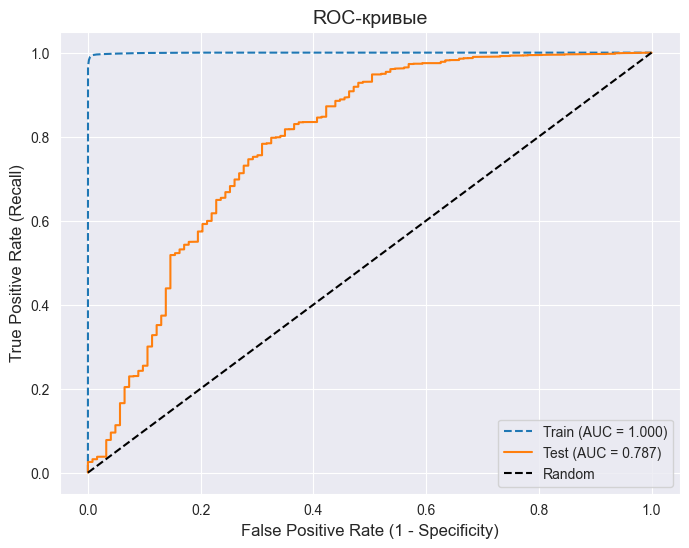

In [118]:
check_metrics(y_train, y_test, y_cat_pred_train, y_cat_pred_test, y_cat_prob_train,
              y_cat_prob_test)

### LightGBM

In [111]:
lgbm_model = LGBMClassifier(max_depth=16,
                            learning_rate=0.1,
                            n_estimators=1000,
                            n_jobs=-1,
                            random_state=RANDOM_STATE)

In [112]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 28672, number of negative: 28672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004918 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10658
[LightGBM] [Info] Number of data points in the train set: 57344, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(max_depth=16, n_estimators=1000, n_jobs=-1, random_state=2004)

In [113]:
y_lgbm_prob_train = lgbm_model.predict_proba(X_train)
y_lgbm_prob_test = lgbm_model.predict_proba(X_test)

y_lgbm_pred_train = lgbm_model.predict(X_train)
y_lgbm_pred_test = lgbm_model.predict(X_test)

Метрики классификации:


,Accuracy,Precision,Recall,F1,ROC AUC
Train,0.9937,0.9943,0.9930,0.9936,0.9997
Test,0.9787,0.9880,0.9904,0.9892,0.7541



Матрица ошибок (Train):
[[28508   164]
 [  200 28472]]

Матрица ошибок (Test):
[[  37   86]
 [  69 7100]]


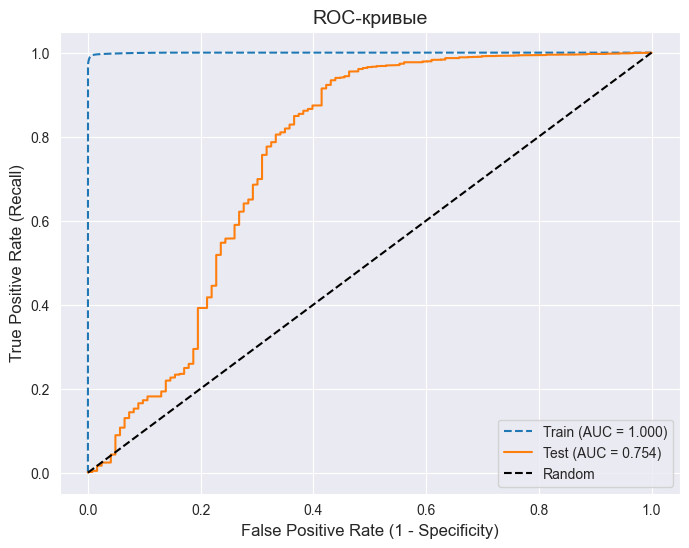

In [114]:
check_metrics(y_train, y_test, y_lgbm_pred_train, y_lgbm_pred_test, y_lgbm_prob_train,
              y_lgbm_prob_test)

### XGBoost

In [123]:
xg_model = XGBClassifier(max_depth=8,
                      n_estimators=300,
                      min_child_weight=8,
                      subsample=0.8,
                      learning_rate =0.1,
                      seed=RANDOM_STATE)

In [124]:
xg_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=8, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [125]:
y_xg_prob_train = xg_model.predict_proba(X_train)
y_xg_prob_test = xg_model.predict_proba(X_test)

y_xg_pred_train = xg_model.predict(X_train)
y_xg_pred_test = xg_model.predict(X_test)

Метрики классификации:


,Accuracy,Precision,Recall,F1,ROC AUC
Train,0.9900,0.9878,0.9922,0.990,0.9988
Test,0.9783,0.9879,0.9901,0.989,0.7277



Матрица ошибок (Train):
[[28322   350]
 [  224 28448]]

Матрица ошибок (Test):
[[  36   87]
 [  71 7098]]


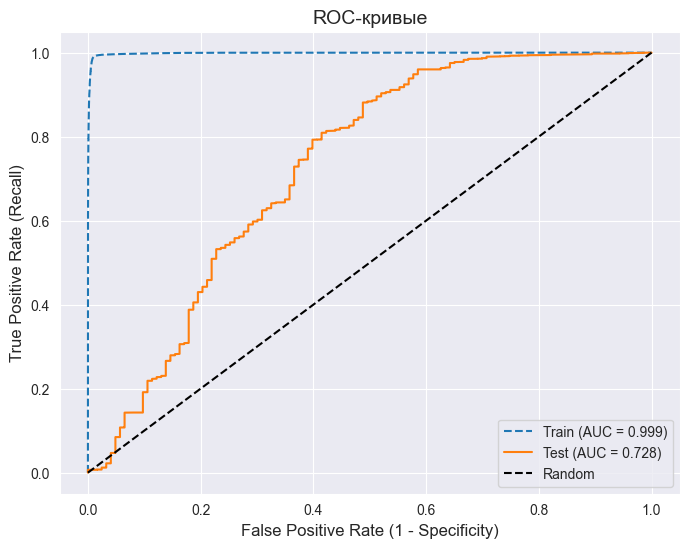

In [126]:
check_metrics(y_train, y_test, y_xg_pred_train, y_xg_pred_test, y_xg_prob_train,
              y_xg_prob_test)